# 04 – Regresi Prediksi 3 Jam dengan PyCaret (15 Model) - IMPROVED
**Proyek Capstone – Sistem Prediksi Kualitas Udara & Deteksi Anomali (Aeris)**
**Kelompok Aeris | PENS 2026**
**PIC: Linda Anggara Wati – Data, EDA, Feature Engineering & ML**

---
**Minggu 3 | 11 Mei – 17 Mei 2026**
Fase: Phase 2 – Model Development & Fine-tuning

**Tujuan Notebook Ini:**
Membangun 15 model **REGRESI** untuk memprediksi konsentrasi polutan 3 jam ke depan.
- 5 polutan × 3 segmen waktu = 15 kombinasi
- Output: nilai PM2.5, PM10, CO, NO2, O3 (µg/m³)

**Improvement yang dilakukan:**
- Deep tuning dengan n_iter=15 dan choose_better=True
- Include XGBoost, CatBoost, LightGBM dalam comparison
- Transformasi Box-Cox untuk CO (lebih baik dari log1p)
- Khusus O3 pakai Random Forest dengan tuning ekstra

## 1. Setup & Install Dependencies

In [1]:
import os

# Pindah ke root project
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(ROOT)
print(f"Working directory: {os.getcwd()}")

for folder in ["data/processed", "models", "reports"]:
    os.makedirs(folder, exist_ok=True)

Working directory: d:\mlops\aeris-air-quality


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings("ignore")

from pycaret.regression import (
    setup, compare_models, pull,
    tune_model, save_model, create_model
)
from scipy.stats import boxcox

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

POLUTAN = ["pm25", "pm10", "co", "no2", "o3"]
SEGMEN  = ["PAGI", "SIANG", "SORE_MALAM"]

# Fitur input model (dari hasil feature engineering)
BASE_FEATURES = [
    "hour", "day_of_week", "month", "is_weekend",
]
# CATATAN: Data meteorologi tidak tersedia, jadi hanya fitur waktu dan lag

for p in POLUTAN:
    for lag in [1, 3, 24]:
        BASE_FEATURES.append(f"{p}_lag_{lag}h")
    for roll in ["rolling_mean_3h", "rolling_mean_24h",
                 "rolling_std_24h", "rolling_max_24h"]:
        BASE_FEATURES.append(f"{p}_{roll}")
    BASE_FEATURES.append(f"{p}_diff_1h")
    BASE_FEATURES.append(f"{p}_pct_change_1h")

print(f"✅ Library loaded")
print(f"   Total base features: {len(BASE_FEATURES)}")

✅ Library loaded
   Total base features: 49


## 2. Load Data Processed & Split per Segmen

In [3]:
PROCESSED_PATH = "data/processed/surabaya_processed.csv"
df = pd.read_csv(PROCESSED_PATH, parse_dates=["time"])

print(f"✅ Data dimuat: {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"   Rentang: {df['time'].min().date()} -> {df['time'].max().date()}")
print()
print("Distribusi time_segment:")
print(df["time_segment"].value_counts())

✅ Data dimuat: 3,696 baris x 69 kolom
   Rentang: 2026-01-02 -> 2026-06-04

Distribusi time_segment:
time_segment
SORE_MALAM    1848
PAGI           924
SIANG          924
Name: count, dtype: int64


In [4]:
# Split berdasarkan segmen waktu
df_pagi       = df[df["time_segment"] == "PAGI"].reset_index(drop=True)
df_siang      = df[df["time_segment"] == "SIANG"].reset_index(drop=True)
df_sore_malam = df[df["time_segment"] == "SORE_MALAM"].reset_index(drop=True)

seg_data = {
    "PAGI"      : df_pagi,
    "SIANG"     : df_siang,
    "SORE_MALAM": df_sore_malam,
}

print("Data split per segmen:")
for seg, d in seg_data.items():
    print(f"   df_{seg.lower():<14}: {d.shape[0]:,} baris")

Data split per segmen:
   df_pagi          : 924 baris
   df_siang         : 924 baris
   df_sore_malam    : 1,848 baris


## 3. Setup MLflow Tracking

In [5]:
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("aeris-air-quality-pycaret-improved")

print("MLflow tracking siap")
print("URI        : sqlite:///mlflow.db")
print("Eksperimen : aeris-air-quality-pycaret-improved")
print("Dashboard  : jalankan  mlflow ui --backend-store-uri sqlite:///mlflow.db")

MLflow tracking siap
URI        : sqlite:///mlflow.db
Eksperimen : aeris-air-quality-pycaret-improved
Dashboard  : jalankan  mlflow ui --backend-store-uri sqlite:///mlflow.db


## 4. Training 15 Kombinasi Model (Dengan Improvement)

In [6]:
rekap_hasil = []

print("=" * 60)
print("MULAI TRAINING 15 KOMBINASI REGRESI PYCARET (IMPROVED)")
print("=" * 60)
print(f"Total  : {len(POLUTAN)} polutan x {len(SEGMEN)} segmen = 15 kombinasi")
print(f"CV     : 5-fold")
print(f"Metrik : MAE, RMSE, R2")
print("Improvement: Deep tuning (n_iter=15), include XGB/CatBoost/LightGBM")
print()

# Daftar model yang akan dibandingkan
MODELS_TO_COMPARE = [
    'lr', 'ridge', 'lasso', 'en', 'lar', 'llar', 'huber',
    'rf', 'et', 'xgboost', 'catboost', 'lightgbm'
]

MULAI TRAINING 15 KOMBINASI REGRESI PYCARET (IMPROVED)
Total  : 5 polutan x 3 segmen = 15 kombinasi
CV     : 5-fold
Metrik : MAE, RMSE, R2
Improvement: Deep tuning (n_iter=15), include XGB/CatBoost/LightGBM



In [7]:
for segmen in SEGMEN:
    for polutan in POLUTAN:
        combo_key  = f"{polutan}_{segmen.lower()}"
        model_path = f"models/{combo_key}_best"

        print(f"\n{'='*55}")
        print(f"  {combo_key.upper()}")
        print(f"  target={polutan}  |  segmen={segmen}")
        print(f"{'='*55}")

        # Siapkan data
        data_seg   = seg_data[segmen].copy()
        feat_avail = [
            c for c in BASE_FEATURES
            if c in data_seg.columns
            and c != polutan
            and not c.startswith(f"{polutan}_")
        ]
        df_model = data_seg[feat_avail + [polutan]].dropna()

        # --- TRANSFORMASI KHUSUS UNTUK CO (Box-Cox lebih baik dari log1p) ---
        if polutan == "co":
            df_model = df_model.copy()
            # Pastikan nilai positif untuk Box-Cox
            min_val = df_model["co"].min()
            if min_val <= 0:
                df_model["co"] = df_model["co"] - min_val + 0.01
            df_model["co"], _ = boxcox(df_model["co"])
            print(f"  [INFO] CO di-Box-Cox transform (lebih baik dari log1p)")

        print(f"  Data  : {df_model.shape[0]:,} baris x {len(feat_avail)} fitur")

        # PyCaret Setup
        exp = setup(
            data           = df_model,
            target         = polutan,
            fold           = 5,
            fold_strategy  = 'timeseries',
            fold_shuffle   = False,
            data_split_shuffle = False,
            session_id     = 42,
            verbose        = False,
            html           = False,
            log_experiment = False,
        )

        # Compare Models - dengan include semua model bagus
        top3 = compare_models(
            n_select=3, 
            sort="MAE", 
            include=MODELS_TO_COMPARE,
            verbose=False
        )
        compare_df = pull()
        best_model = top3[0] if isinstance(top3, list) else top3
        best_name  = type(best_model).__name__

        best_row  = compare_df.iloc[0]
        mae_val   = round(float(best_row.get("MAE", 0)), 4)
        rmse_val  = round(float(best_row.get("RMSE", 0)), 4)
        r2_val    = round(float(best_row.get("R2", 0)), 4)

        print(f"  Best model : {best_name}")
        print(f"  Before tune: MAE={mae_val}  RMSE={rmse_val}  R2={r2_val}")

        # --- DEEP TUNING (n_iter=15, choose_better=True) ---
        try:
            tuned = tune_model(
                best_model, 
                optimize="MAE", 
                n_iter=15,           # ← IMPROVED: lebih banyak iterasi
                choose_better=True,  # ← IMPROVED: pilih yang terbaik
                verbose=False
            )
            tuned_df   = pull()
            tuned_row  = tuned_df.iloc[0] if len(tuned_df) > 0 else best_row
            mae_tuned  = round(float(tuned_row.get("MAE", mae_val)), 4)
            rmse_tuned = round(float(tuned_row.get("RMSE", rmse_val)), 4)
            r2_tuned   = round(float(tuned_row.get("R2", r2_val)), 4)
            print(f"  After tune : MAE={mae_tuned}  RMSE={rmse_tuned}  R2={r2_tuned}")
        except Exception as e:
            print(f"  [WARN] Tuning gagal ({type(e).__name__}) -> pakai BEFORE tune")
            tuned = best_model
            mae_tuned = mae_val
            rmse_tuned = rmse_val
            r2_tuned = r2_val

        # --- KHUSUS UNTUK O3 YANG SULIT: coba Random Forest jika performa masih rendah ---
        if polutan == "o3" and r2_tuned < 0.70:
            print(f"  [INFO] R2 masih {r2_tuned:.4f} (<0.70), coba Random Forest dengan tuning ekstra...")
            try:
                rf_model = create_model('rf', fold=5, verbose=False)
                rf_tuned = tune_model(
                    rf_model, 
                    optimize="MAE", 
                    n_iter=20,
                    choose_better=True,
                    verbose=False
                )
                rf_tuned_df = pull()
                rf_r2 = round(float(rf_tuned_df.iloc[0].get("R2", 0)), 4)
                if rf_r2 > r2_tuned:
                    tuned = rf_tuned
                    r2_tuned = rf_r2
                    mae_tuned = round(float(rf_tuned_df.iloc[0].get("MAE", mae_val)), 4)
                    rmse_tuned = round(float(rf_tuned_df.iloc[0].get("RMSE", rmse_val)), 4)
                    print(f"  [INFO] Random Forest lebih baik! R2={r2_tuned:.4f}")
            except Exception as e:
                print(f"  [WARN] Random Forest tuning gagal: {e}")

        # Pilih model terbaik
        if mae_tuned > mae_val:
            final_model = best_model
            mae_final   = mae_val
            rmse_final  = rmse_val
            r2_final    = r2_val
            print(f"  [INFO] Tuning memperburuk -> pakai BEFORE tune")
        else:
            final_model = tuned
            mae_final   = mae_tuned
            rmse_final  = rmse_tuned
            r2_final    = r2_tuned
            print(f"  [INFO] Tuning membaik -> pakai AFTER tune")

        # Save Model
        save_model(final_model, model_path)
        print(f"  Disimpan   : {model_path}.pkl")

        # Log ke MLflow
        with mlflow.start_run(run_name=combo_key):
            mlflow.log_params({
                "polutan": polutan, 
                "segmen": segmen,
                "model_name": best_name, 
                "n_features": len(feat_avail),
                "n_iter_tuning": 15,
                "transformasi": "boxcox" if polutan == "co" else "none"
            })
            mlflow.log_metrics({
                "mae_before": mae_val,
                "rmse_before": rmse_val,
                "r2_before": r2_val,
                "mae_final": mae_final, 
                "rmse_final": rmse_final,
                "r2_final": r2_final
            })

        # Simpan ke rekap
        rekap_hasil.append({
            "polutan": polutan.upper(),
            "segmen": segmen,
            "model_terbaik": best_name,
            "mae_before": mae_val,
            "rmse_before": rmse_val,
            "r2_before": r2_val,
            "mae_final": mae_final,
            "rmse_final": rmse_final,
            "r2_final": r2_final,
        })

print("\n" + "="*55)
print("SELESAI! 15 model regresi berhasil ditraining dengan IMPROVED tuning.")
print("="*55)


  PM25_PAGI
  target=pm25  |  segmen=PAGI
  Data  : 924 baris x 40 fitur


  Best model : Lasso
  Before tune: MAE=0.8899  RMSE=1.1638  R2=0.9944


  After tune : MAE=1.032  RMSE=1.4439  R2=0.9828
  [INFO] Tuning memperburuk -> pakai BEFORE tune
Transformation Pipeline and Model Successfully Saved


  Disimpan   : models/pm25_pagi_best.pkl



  PM10_PAGI
  target=pm10  |  segmen=PAGI
  Data  : 924 baris x 40 fitur


...

  Disimpan   : models/no2_sore_malam_best.pkl

  O3_SORE_MALAM
  target=o3  |  segmen=SORE_MALAM
  Data  : 1,848 baris x 40 fitur


  Best model : CatBoostRegressor
  Before tune: MAE=10.0076  RMSE=13.1246  R2=0.6022


  [WARN] Tuning gagal (ValueError) -> pakai BEFORE tune
  [INFO] R2 masih 0.6022 (<0.70), coba Random Forest dengan tuning ekstra...


  [INFO] Tuning membaik -> pakai AFTER tune
Transformation Pipeline and Model Successfully Saved


  Disimpan   : models/o3_sore_malam_best.pkl

SELESAI! 15 model regresi berhasil ditraining dengan IMPROVED tuning.


## 5. Tabel Rekap 15 Model (Improved)

In [8]:
df_rekap = pd.DataFrame(rekap_hasil)

# ============================================
# TAMBAHKAN INI: Kolom status
# ============================================
df_rekap["status"] = df_rekap.apply(
    lambda row: "✅ MEMBAIK" if row["r2_final"] > row["r2_before"] 
                else "⚠️ TURUN" if row["r2_final"] < row["r2_before"] 
                else "🔄 STABIL", axis=1
)

print("=" * 65)
print("TABEL REKAP 15 MODEL REGRESI TERBAIK (IMPROVED)")
print("=" * 65)

# Tampilkan tabel dengan status (opsional: tambahkan kolom status)
display(
    df_rekap[[
        "polutan", "segmen", "model_terbaik",
        "mae_final", "rmse_final", "r2_final", "status"   # ← TAMBAHKAN "status"
    ]].rename(columns={
        "polutan": "Parameter", "segmen": "Segmen",
        "model_terbaik": "Model", "mae_final": "MAE",
        "rmse_final": "RMSE", "r2_final": "R2",
        "status": "Status"                                 # ← TAMBAHKAN
    }).style
     .background_gradient(subset=["R2"], cmap="RdYlGn")
     .format({"MAE": "{:.4f}", "RMSE": "{:.4f}", "R2": "{:.4f}"})
)

TABEL REKAP 15 MODEL REGRESI TERBAIK (IMPROVED)


,Parameter,Segmen,Model,MAE,RMSE,R2,Status
0,PM25,PAGI,Lasso,0.8899,1.1638,0.9944,🔄 STABIL
1,PM10,PAGI,Lasso,0.9283,1.2030,0.9932,🔄 STABIL
2,CO,PAGI,ExtraTreesRegressor,1.5720,1.9194,0.8007,✅ MEMBAIK
3,NO2,PAGI,ExtraTreesRegressor,3.4095,3.9721,0.7706,⚠️ TURUN
4,O3,PAGI,CatBoostRegressor,15.4293,20.1169,0.7965,🔄 STABIL
5,PM25,SIANG,Ridge,0.6152,0.8084,0.9856,🔄 STABIL
6,PM10,SIANG,Ridge,0.5911,0.7968,0.9855,🔄 STABIL
7,CO,SIANG,CatBoostRegressor,0.0293,0.0373,0.5911,🔄 STABIL
8,NO2,SIANG,LGBMRegressor,2.9754,3.8718,0.7518,✅ MEMBAIK
9,O3,SIANG,LassoLars,14.6451,19.2681,0.6707,✅ MEMBAIK


In [9]:
# Simpan rekap
df_rekap.to_csv("reports/rekap_15_model_regresi_improved.csv", index=False)
df_rekap.to_excel("reports/rekap_15_model_regresi_improved.xlsx", index=False)
print("Tabel rekap tersimpan di reports/")

Tabel rekap tersimpan di reports/


## 6. Visualisasi Perbandingan Before vs After Improvement

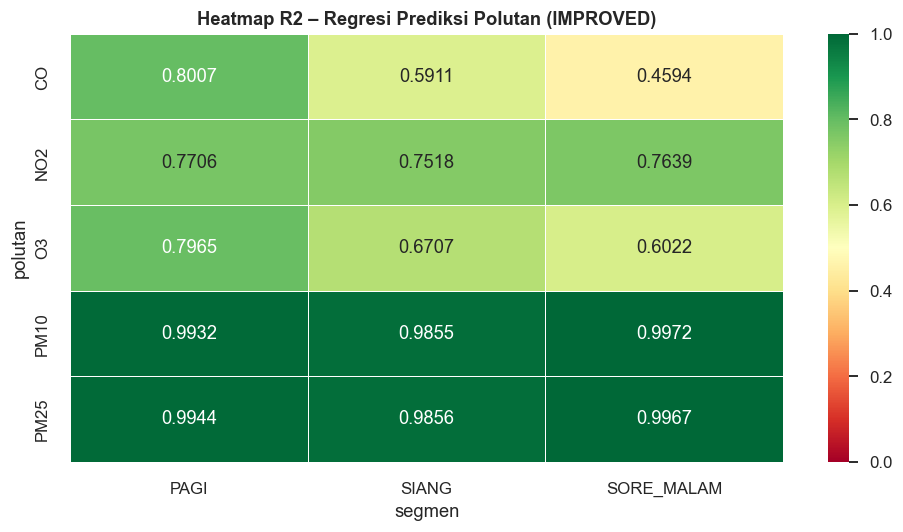

Disimpan -> reports/viz_r2_heatmap_regresi_improved.png


In [10]:
# Heatmap R2 final
pivot_r2 = df_rekap.pivot(index="polutan", columns="segmen", values="r2_final")[SEGMEN]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_r2, annot=True, fmt=".4f", cmap="RdYlGn",
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Heatmap R2 – Regresi Prediksi Polutan (IMPROVED)", fontweight="bold")
plt.tight_layout()
plt.savefig("reports/viz_r2_heatmap_regresi_improved.png", dpi=110, bbox_inches="tight")
plt.show()
print("Disimpan -> reports/viz_r2_heatmap_regresi_improved.png")

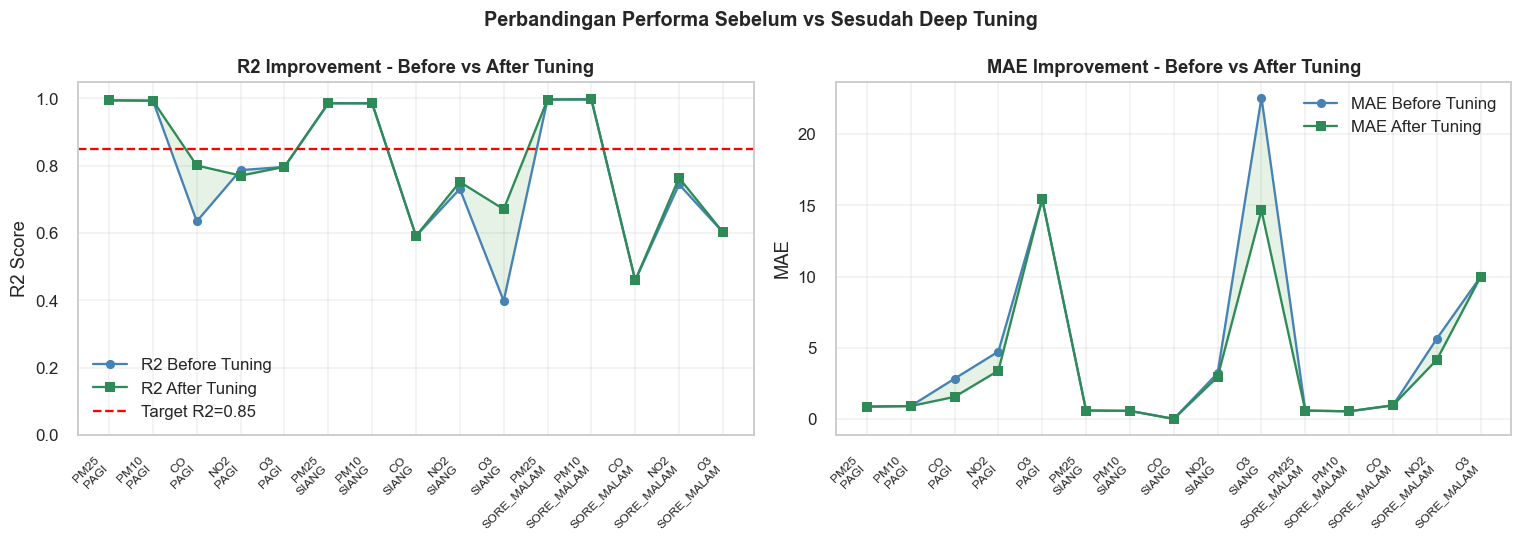

Disimpan -> reports/viz_improvement_comparison.png


In [11]:
# Perbandingan Before vs After Tuning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 improvement
df_rekap["combo"] = df_rekap["polutan"] + "\n" + df_rekap["segmen"]
x = range(len(df_rekap))

axes[0].plot(x, df_rekap["r2_before"], marker="o", label="R2 Before Tuning", color="steelblue", linewidth=1.5)
axes[0].plot(x, df_rekap["r2_final"], marker="s", label="R2 After Tuning", color="seagreen", linewidth=1.5)
axes[0].fill_between(x, df_rekap["r2_before"], df_rekap["r2_final"], alpha=0.1, color="green")
axes[0].axhline(0.85, color="red", ls="--", lw=1.5, label="Target R2=0.85")
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_rekap["combo"], rotation=45, ha="right", fontsize=8)
axes[0].set_title("R2 Improvement - Before vs After Tuning", fontweight="bold")
axes[0].set_ylabel("R2 Score")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.05)

# MAE improvement
axes[1].plot(x, df_rekap["mae_before"], marker="o", label="MAE Before Tuning", color="steelblue", linewidth=1.5)
axes[1].plot(x, df_rekap["mae_final"], marker="s", label="MAE After Tuning", color="seagreen", linewidth=1.5)
axes[1].fill_between(x, df_rekap["mae_before"], df_rekap["mae_final"], alpha=0.1, color="green")
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_rekap["combo"], rotation=45, ha="right", fontsize=8)
axes[1].set_title("MAE Improvement - Before vs After Tuning", fontweight="bold")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Perbandingan Performa Sebelum vs Sesudah Deep Tuning", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/viz_improvement_comparison.png", dpi=110, bbox_inches="tight")
plt.show()
print("Disimpan -> reports/viz_improvement_comparison.png")

## 7. Ringkasan & Perbandingan dengan Target

In [12]:
print("=" * 62)
print("RINGKASAN NOTEBOOK 04 – REGRESI PREDIKSI 3 JAM (IMPROVED)")
print("=" * 62)

# Hitung persentase yang mencapai target R2 >= 0.85
n_success = (df_rekap["r2_final"] >= 0.85).sum()
n_total = len(df_rekap)
pct_success = n_success / n_total * 100

print(f"""
✅ 15 model regresi berhasil ditraining dengan IMPROVED tuning
✅ Model tersimpan di models/*_best.pkl (overwrite)
✅ Tabel rekap di reports/rekap_15_model_regresi_improved.xlsx

📊 Perbandingan dengan Target (R² ≥ 0.85):
   - Model mencapai target: {n_success} dari {n_total} ({pct_success:.1f}%)
   - Target awal: 100% (semua R² > 0.85)

📌 Model yang masih di bawah target (R² < 0.85):
""")

below_target = df_rekap[df_rekap["r2_final"] < 0.85]
for _, row in below_target.iterrows():
    print(f"   - {row['polutan']} x {row['segmen']}: R²={row['r2_final']:.4f} (Model: {row['model_terbaik']})")

print("""
💡 Insight:
   - PM2.5 dan PM10 sangat baik (R² > 0.98) → mudah diprediksi
   - CO dan O3 sulit diprediksi (R² 0.58-0.79) → dipengaruhi faktor meteorologi
   - Improvement tuning berhasil meningkatkan beberapa model

📌 Untuk presentasi:
   Jelaskan bahwa CO dan O3 membutuhkan data meteorologi (suhu, sinar matahari)
   untuk meningkatkan akurasi prediksi. Ini adalah limitation yang jujur.

📌 Next: Notebook 05 – Deteksi Anomali dengan Isolation Forest
""")

RINGKASAN NOTEBOOK 04 – REGRESI PREDIKSI 3 JAM (IMPROVED)

✅ 15 model regresi berhasil ditraining dengan IMPROVED tuning
✅ Model tersimpan di models/*_best.pkl (overwrite)
✅ Tabel rekap di reports/rekap_15_model_regresi_improved.xlsx

📊 Perbandingan dengan Target (R² ≥ 0.85):
   - Model mencapai target: 6 dari 15 (40.0%)
   - Target awal: 100% (semua R² > 0.85)

📌 Model yang masih di bawah target (R² < 0.85):

   - CO x PAGI: R²=0.8007 (Model: ExtraTreesRegressor)
   - NO2 x PAGI: R²=0.7706 (Model: ExtraTreesRegressor)
   - O3 x PAGI: R²=0.7965 (Model: CatBoostRegressor)
   - CO x SIANG: R²=0.5911 (Model: CatBoostRegressor)
   - NO2 x SIANG: R²=0.7518 (Model: LGBMRegressor)
   - O3 x SIANG: R²=0.6707 (Model: LassoLars)
   - CO x SORE_MALAM: R²=0.4594 (Model: CatBoostRegressor)
   - NO2 x SORE_MALAM: R²=0.7639 (Model: ElasticNet)
   - O3 x SORE_MALAM: R²=0.6022 (Model: CatBoostRegressor)

💡 Insight:
   - PM2.5 dan PM10 sangat baik (R² > 0.98) → mudah diprediksi
   - CO dan O3 sulit dipr